# Scalability experiments

The analysis below uses one validated long-form table for every plot. A CVaR timeout contributes a **capped wall time of 86,400 seconds** and is reported separately in the timeout rate. Success rates use all replicates; eta summaries use only successful, completed runs.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.lines import Line2D

EXPERIMENTS_DIR = Path(".") if Path("results").exists() else Path("experiments")
RESULTS_DIR = EXPERIMENTS_DIR / "results"
analysis_path = str(EXPERIMENTS_DIR.resolve())
if analysis_path not in sys.path:
    sys.path.insert(0, analysis_path)

import scalability_analysis as sa  # noqa: E402

K_GRID = [5, 10, 30, 100, 250, 500]
PLOT_K_GRID = [30, 100, 250, 500]
N_GRID = [5, 10, 20, 50]
RISK_GRID = ["msd", "cvar"]
METHODS = [*sa.SCALABILITY_METHODS, "higher_eps_screened_dual", "uniform"]
cmap = plt.get_cmap("tab10")
COLORS = {method: cmap(i % cmap.N) for i, method in enumerate(METHODS)}

In [2]:
msd_wide = sa.load_csv_shards(
    RESULTS_DIR / "remote/msd_cvar_part_scalability", "*K*_n*.csv"
)
msd_wide = msd_wide.loc[msd_wide["risk"].ne("cvar")].copy()

cvar_capped = pd.read_csv(
    RESULTS_DIR / "remote/cvar_scalability/capped_24h_v1/capped_method_results.csv"
)
cvar_wide = sa.capped_results_to_wide(cvar_capped)

expected_rows_per_risk = len(K_GRID) * len(N_GRID) * 20
assert len(msd_wide) == expected_rows_per_risk
assert len(cvar_wide) == expected_rows_per_risk

# Keep the familiar one-row-per-replicate dataframe for interactive inspection.
df = pd.concat([msd_wide, cvar_wide], ignore_index=True, sort=False)
assert not df.duplicated(["risk", "K", "n", "seed"]).any()

higher_epsilon = sa.load_csv_shards(RESULTS_DIR / "remote/higher_eps/v1", "*K*_n*.csv")
df = sa.merge_higher_epsilon_screened_dual(df, higher_epsilon)

scalability_long = sa.wide_scalability_to_long(
    df, methods=[*sa.SCALABILITY_METHODS, "higher_eps_screened_dual"]
)
uniform = pd.read_csv(RESULTS_DIR / "uniform/uniform_profile_baseline.csv")
scalability_long = sa.append_uniform_baseline(scalability_long, uniform)
scalability_summary = sa.summarize_scalability(scalability_long)

coverage = (
    scalability_long.groupby(["risk", "method"], as_index=False)
    .agg(replicate_method_rows=("seed", "size"))
    .sort_values(["risk", "method"])
)
coverage

,risk,method,replicate_method_rows
0,cvar,action_dual,480
1,cvar,higher_eps_screened_dual,120
2,cvar,mcp,480
3,cvar,restricted_mcp,480
4,cvar,screened_dual,480
5,cvar,stochastic_full_batch,480
6,cvar,stochastic_minibatch,480
7,cvar,uniform,320
8,msd,action_dual,480
9,msd,higher_eps_screened_dual,120


In [3]:
scalability_summary.sort_values(["risk", "n", "K", "method"])

,risk,n,K,method,reps,successes,timeouts,capped_time_median,capped_time_q25,capped_time_q75,success_rate,timeout_rate,eta_reps,eta_median,eta_q25,eta_q75
0,cvar,5,5,action_dual,20,20,0,2.604537,0.207016,12.187150,1.0,0.0,20,0.003803,1.825360e-03,5.972884e-03
1,cvar,5,5,mcp,20,20,0,0.053134,0.049695,0.055491,1.0,0.0,20,0.0,0.000000e+00,1.110223e-16
2,cvar,5,5,restricted_mcp,20,18,0,0.215713,0.072859,0.885675,0.9,0.0,18,0.0,2.775558e-16,5.030133e-03
3,cvar,5,5,screened_dual,20,20,0,3.434065,1.248405,11.577244,1.0,0.0,20,0.00231,2.506761e-11,6.915827e-03
4,cvar,5,5,stochastic_full_batch,20,0,0,265.734135,263.682789,268.709668,0.0,0.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
327,msd,50,500,restricted_mcp,20,0,0,85.593491,67.360075,111.553018,0.0,0.0,0,NaN,NaN,NaN
328,msd,50,500,screened_dual,20,20,0,3709.55784,3078.377867,4958.853983,1.0,0.0,20,0.005582,4.781551e-03,6.543624e-03
329,msd,50,500,stochastic_full_batch,20,20,0,0.234072,0.216610,0.248833,1.0,0.0,20,0.001582,1.470366e-03,1.846999e-03
330,msd,50,500,stochastic_minibatch,20,20,0,0.229936,0.213680,0.245181,1.0,0.0,20,0.001582,1.470366e-03,1.846999e-03


In [4]:
def plot_scalability_grid(
    summary,
    metric,
    ylabel,
    *,
    q25=None,
    q75=None,
    yscale=None,
    ylim=None,
    mark_zero_success=False,
):
    fig, axes = plt.subplots(
        len(RISK_GRID),
        len(N_GRID),
        figsize=(15, 7),
        dpi=600,
        sharex=True,
        sharey=True,
    )

    for row, risk in enumerate(RISK_GRID):
        for col, n in enumerate(N_GRID):
            ax = axes[row, col]
            panel = summary.loc[
                summary["risk"].eq(risk)
                & summary["n"].eq(n)
                & summary["K"].isin(PLOT_K_GRID)
            ]

            for method in METHODS:
                points = panel.loc[panel["method"].eq(method)].sort_values("K")
                points = points.loc[points[metric].notna()]
                if points.empty:
                    continue

                ax.plot(
                    points["K"].to_numpy(),
                    points[metric].to_numpy(),
                    "-",
                    color=COLORS[method],
                )
                if q25 is not None and q75 is not None:
                    band = points.dropna(subset=[q25, q75])
                    ax.fill_between(
                        band["K"].to_numpy(),
                        band[q25].to_numpy(),
                        band[q75].to_numpy(),
                        alpha=0.15,
                        color=COLORS[method],
                    )

                zero_success = points["successes"].eq(0) if mark_zero_success else False
                if mark_zero_success:
                    ordinary = points.loc[~zero_success]
                    failed = points.loc[zero_success]
                else:
                    ordinary = points
                    failed = points.iloc[0:0]
                ax.scatter(
                    ordinary["K"],
                    ordinary[metric],
                    marker="o",
                    s=28,
                    zorder=4,
                    color=COLORS[method],
                )
                ax.scatter(
                    failed["K"],
                    failed[metric],
                    marker="x",
                    s=70,
                    linewidths=2.0,
                    zorder=5,
                    color=COLORS[method],
                )

            if yscale is not None:
                ax.set_yscale(yscale)
            if ylim is not None:
                ax.set_ylim(*ylim)
            ax.set_title(f"{risk.upper()}, n={n}")
            ax.set_xlabel("K")
            ax.set_xticks(PLOT_K_GRID)
            ax.grid(alpha=0.25)
        axes[row, 0].set_ylabel(ylabel)

    present = set(summary["method"])
    legend_methods = [method for method in METHODS if method in present]
    handles = [
        Line2D([0], [0], color=COLORS[method], marker="o", label=method)
        for method in legend_methods
    ]
    if mark_zero_success:
        handles.append(
            Line2D(
                [0],
                [0],
                color="black",
                marker="x",
                linestyle="none",
                label="zero successful reps",
            )
        )
    axes[0, -1].legend(
        handles=handles, frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left"
    )
    plt.tight_layout()
    return fig, axes

A timeout is not an observed 24-hour completion. The runtime figure therefore says **capped wall time**; the next two figures separately show success and timeout rates.

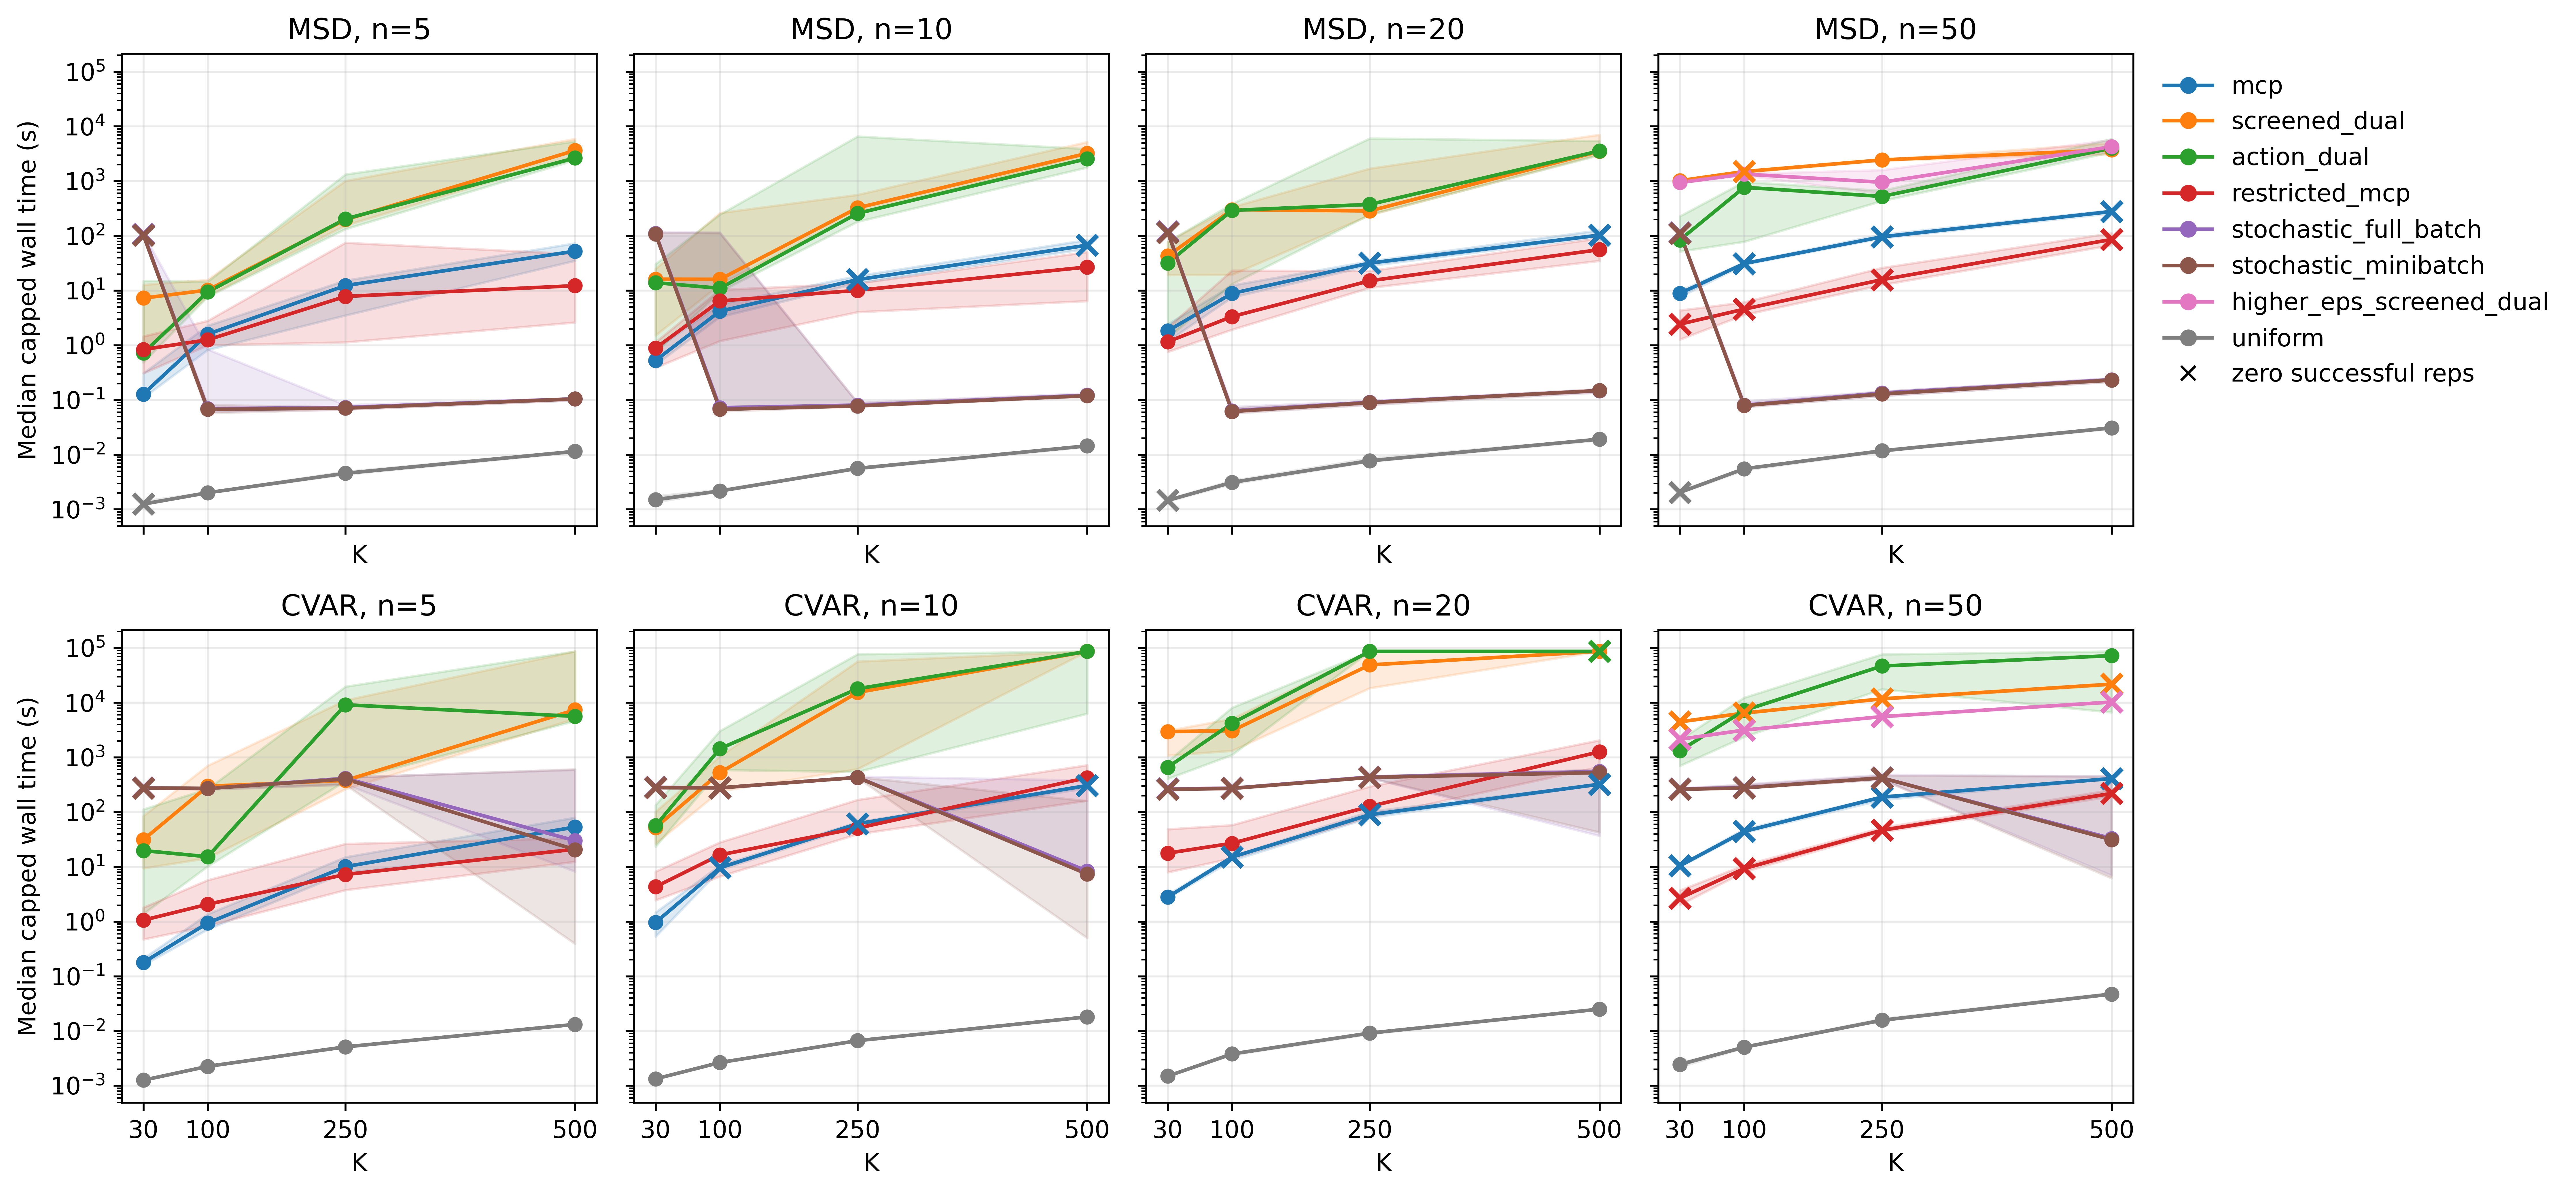

In [5]:
plot_scalability_grid(
    scalability_summary,
    "capped_time_median",
    "Median capped wall time (s)",
    q25="capped_time_q25",
    q75="capped_time_q75",
    yscale="log",
    mark_zero_success=True,
)
plt.show()

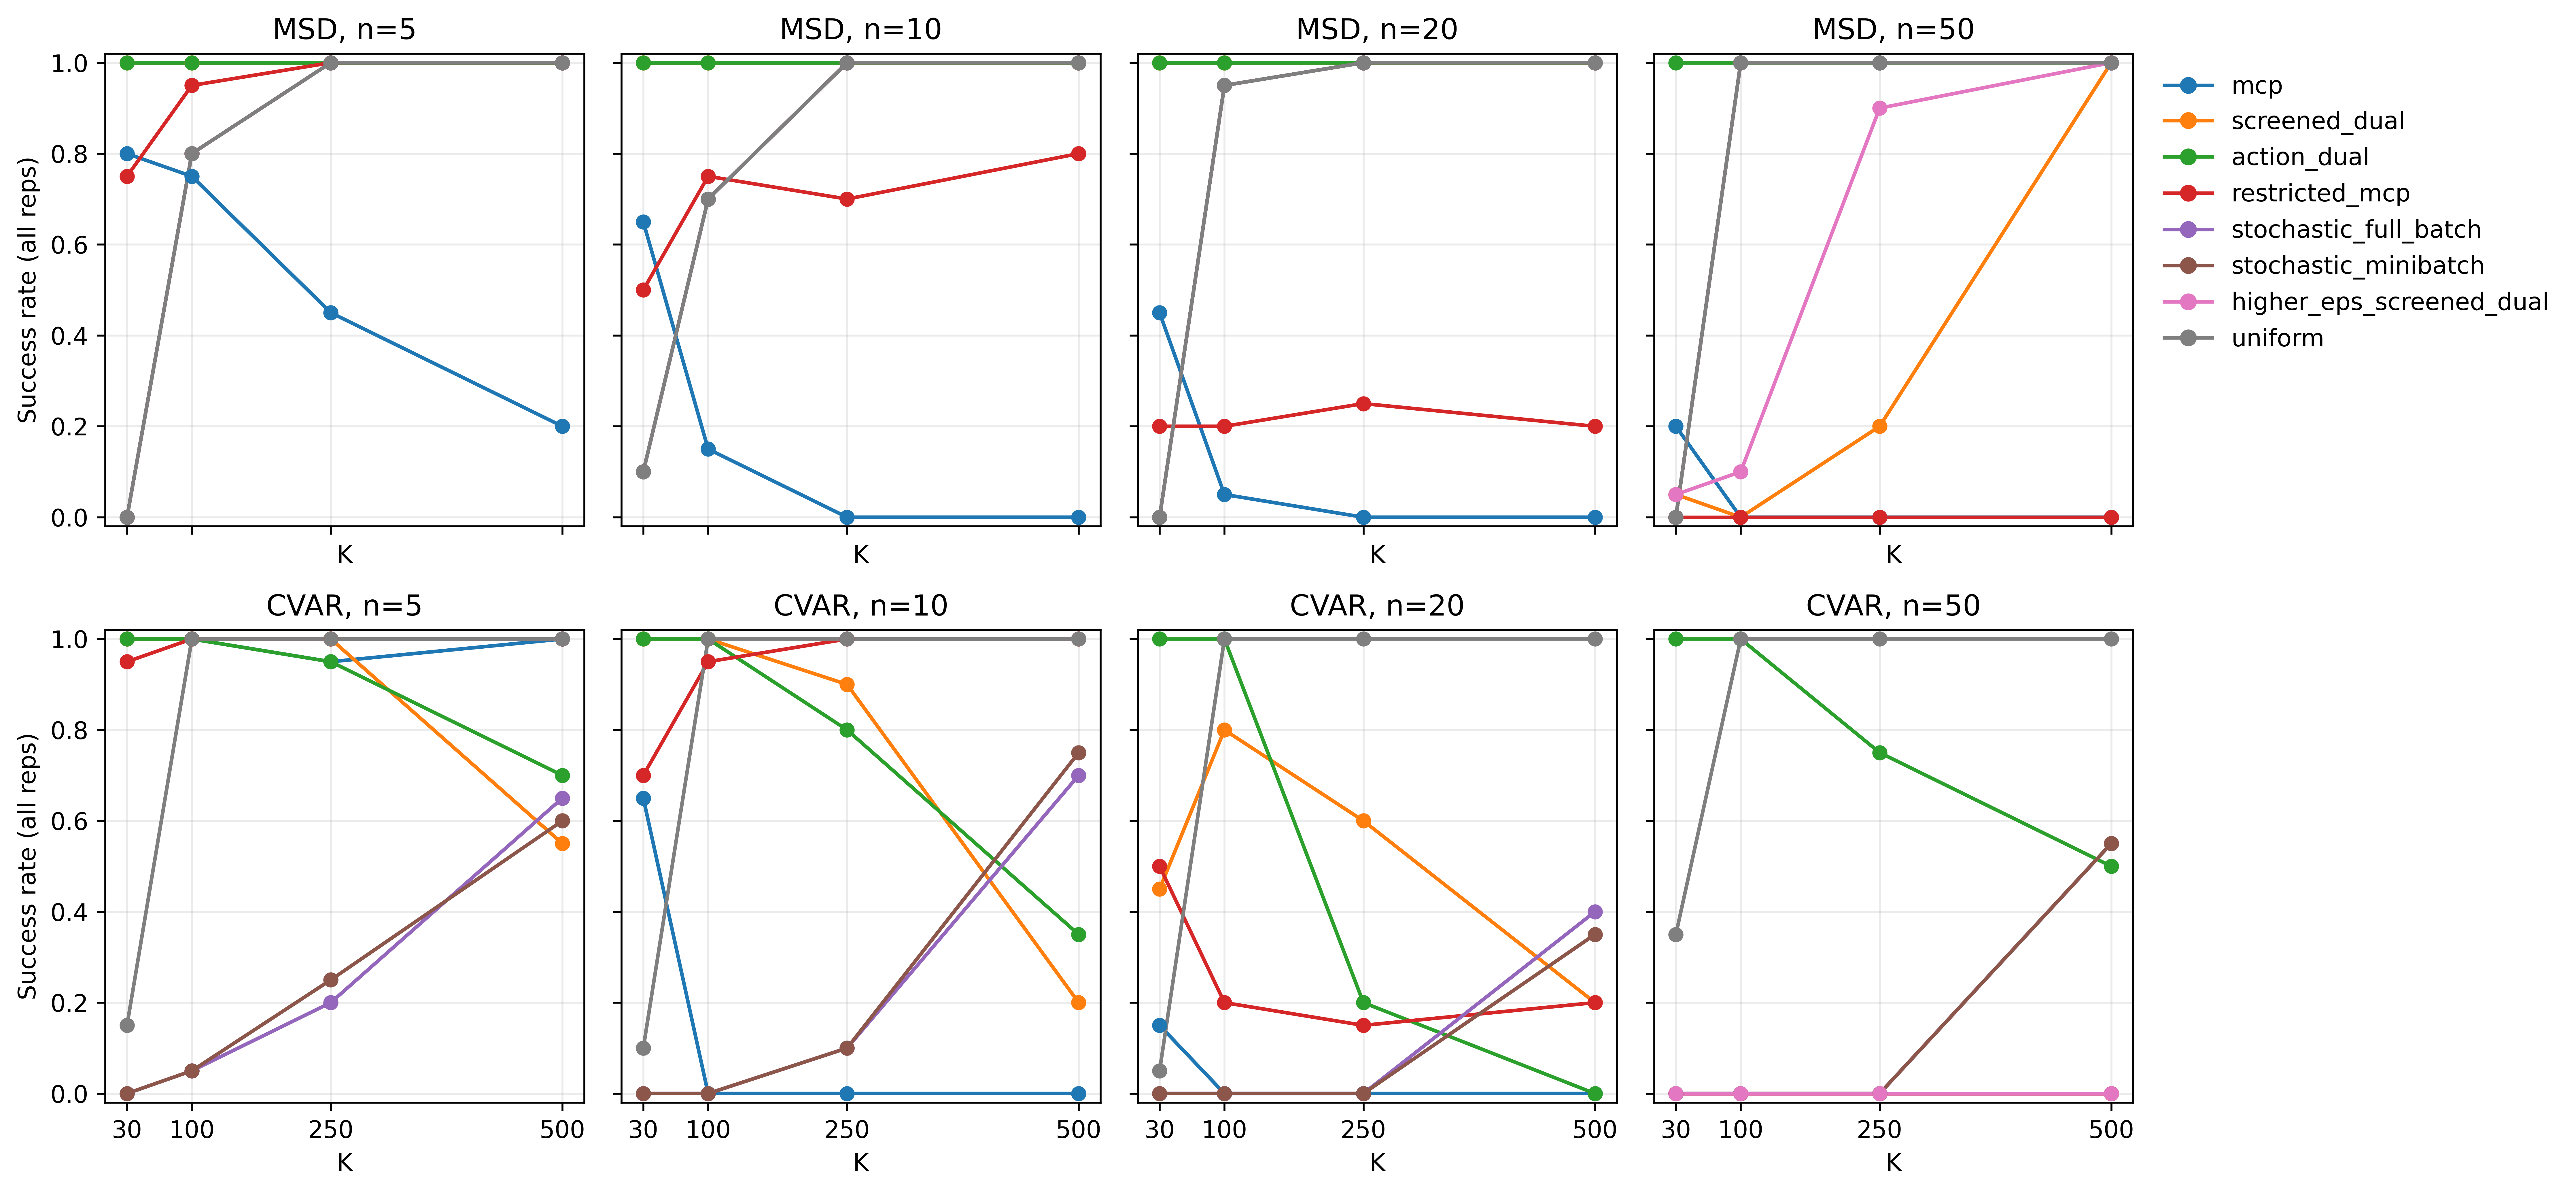

In [6]:
plot_scalability_grid(
    scalability_summary,
    "success_rate",
    "Success rate (all reps)",
    ylim=(-0.02, 1.02),
)
plt.show()

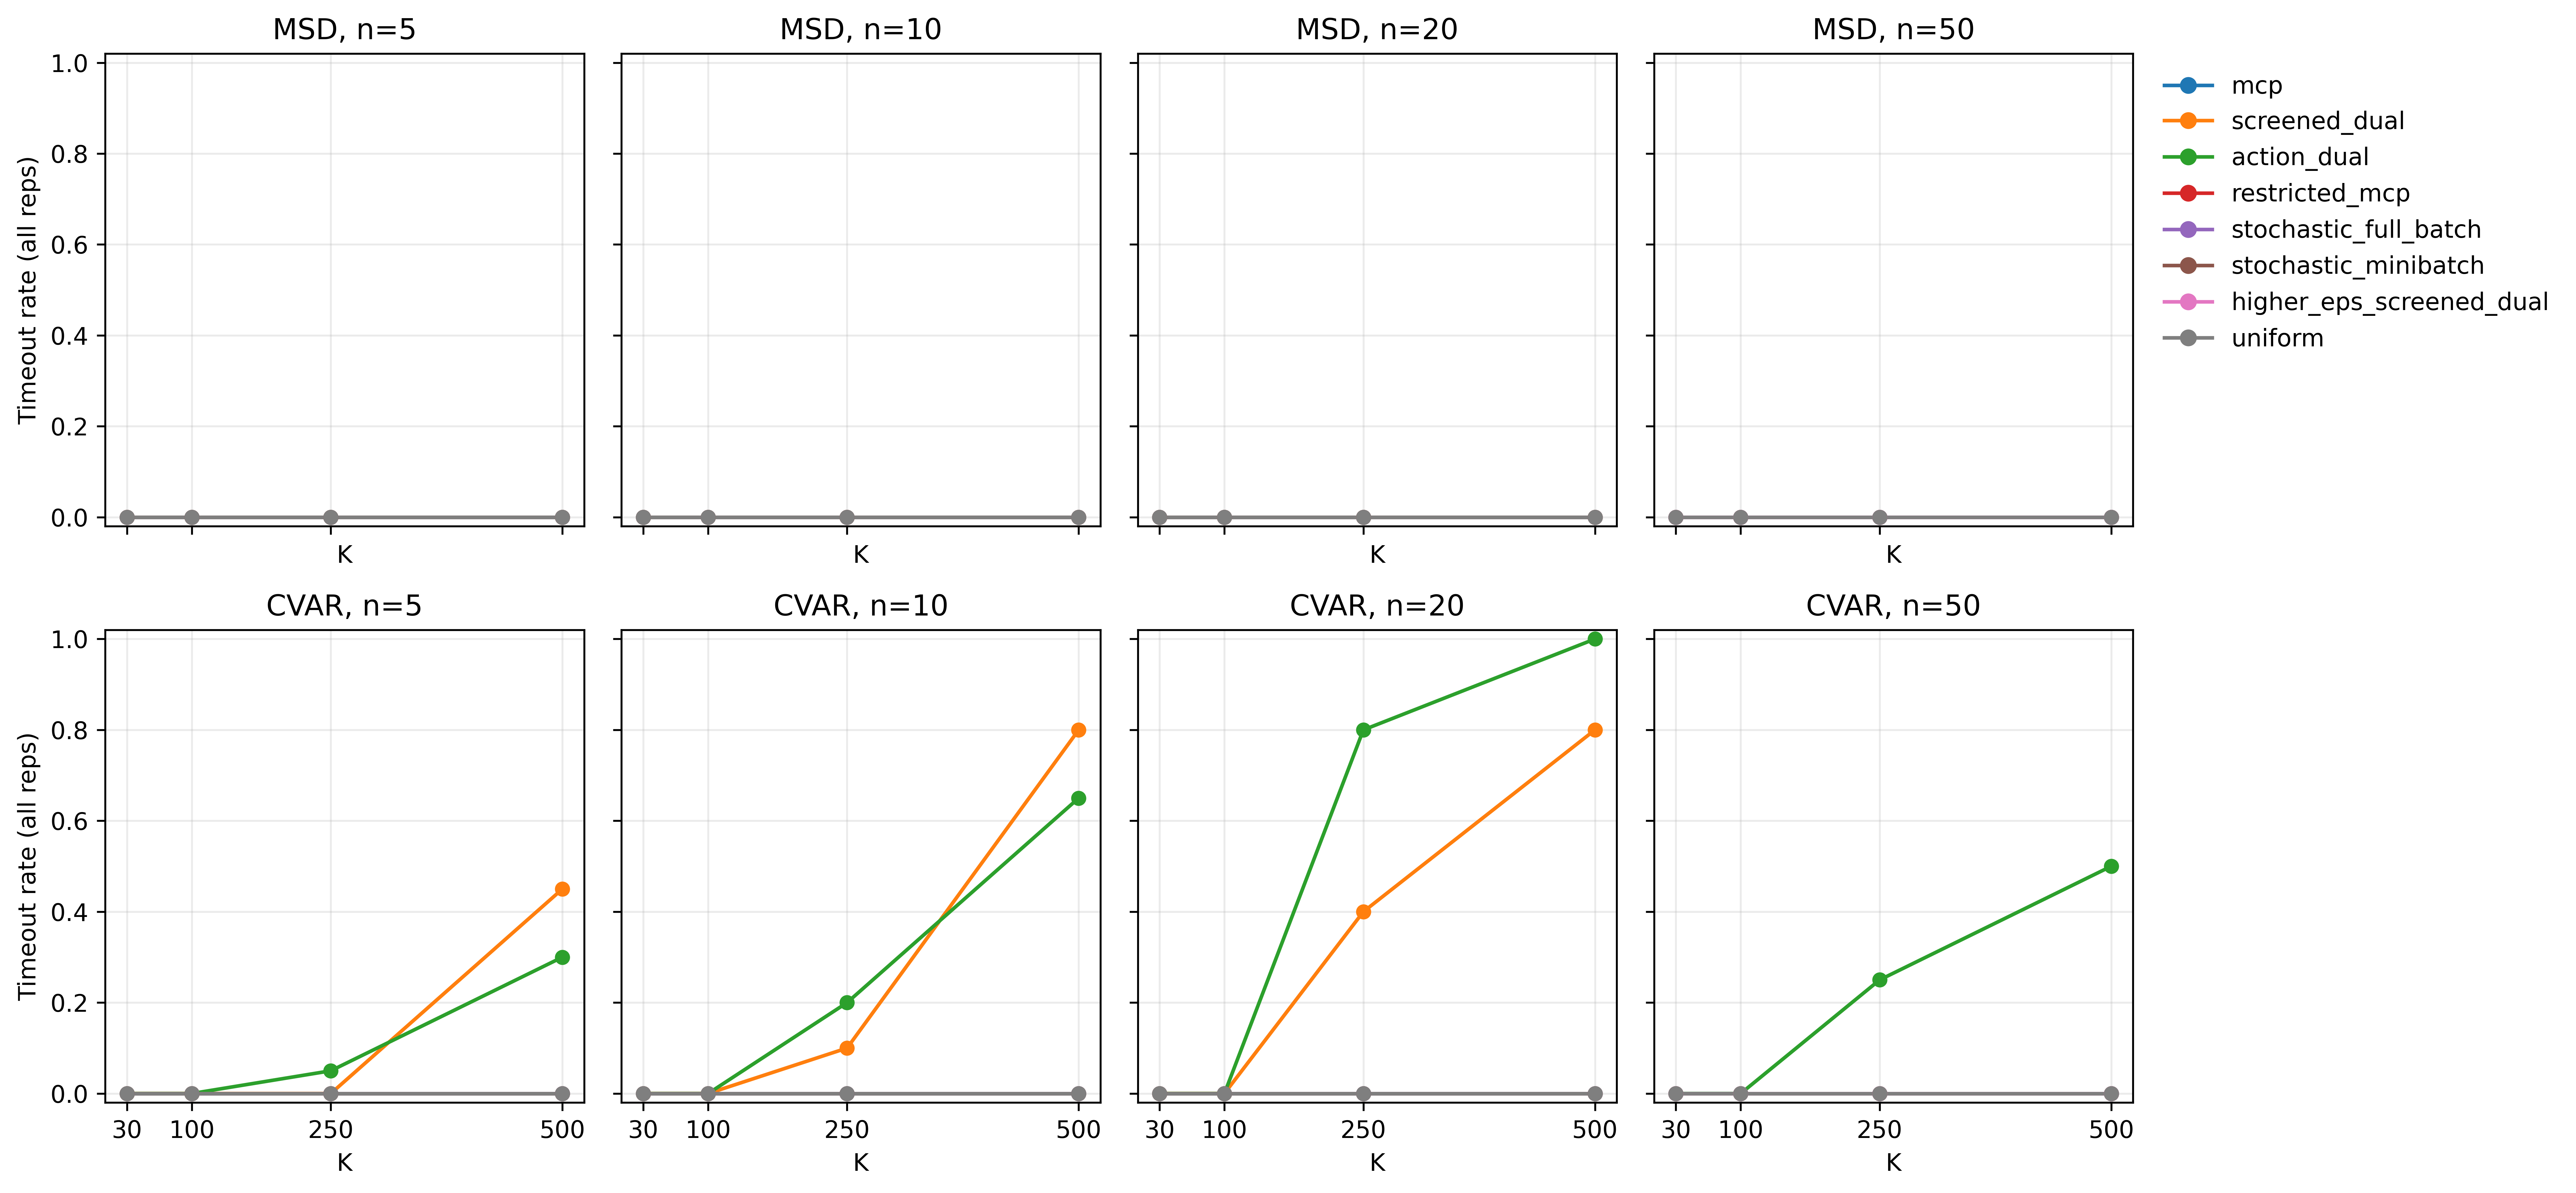

In [7]:
plot_scalability_grid(
    scalability_summary,
    "timeout_rate",
    "Timeout rate (all reps)",
    ylim=(-0.02, 1.02),
)
plt.show()

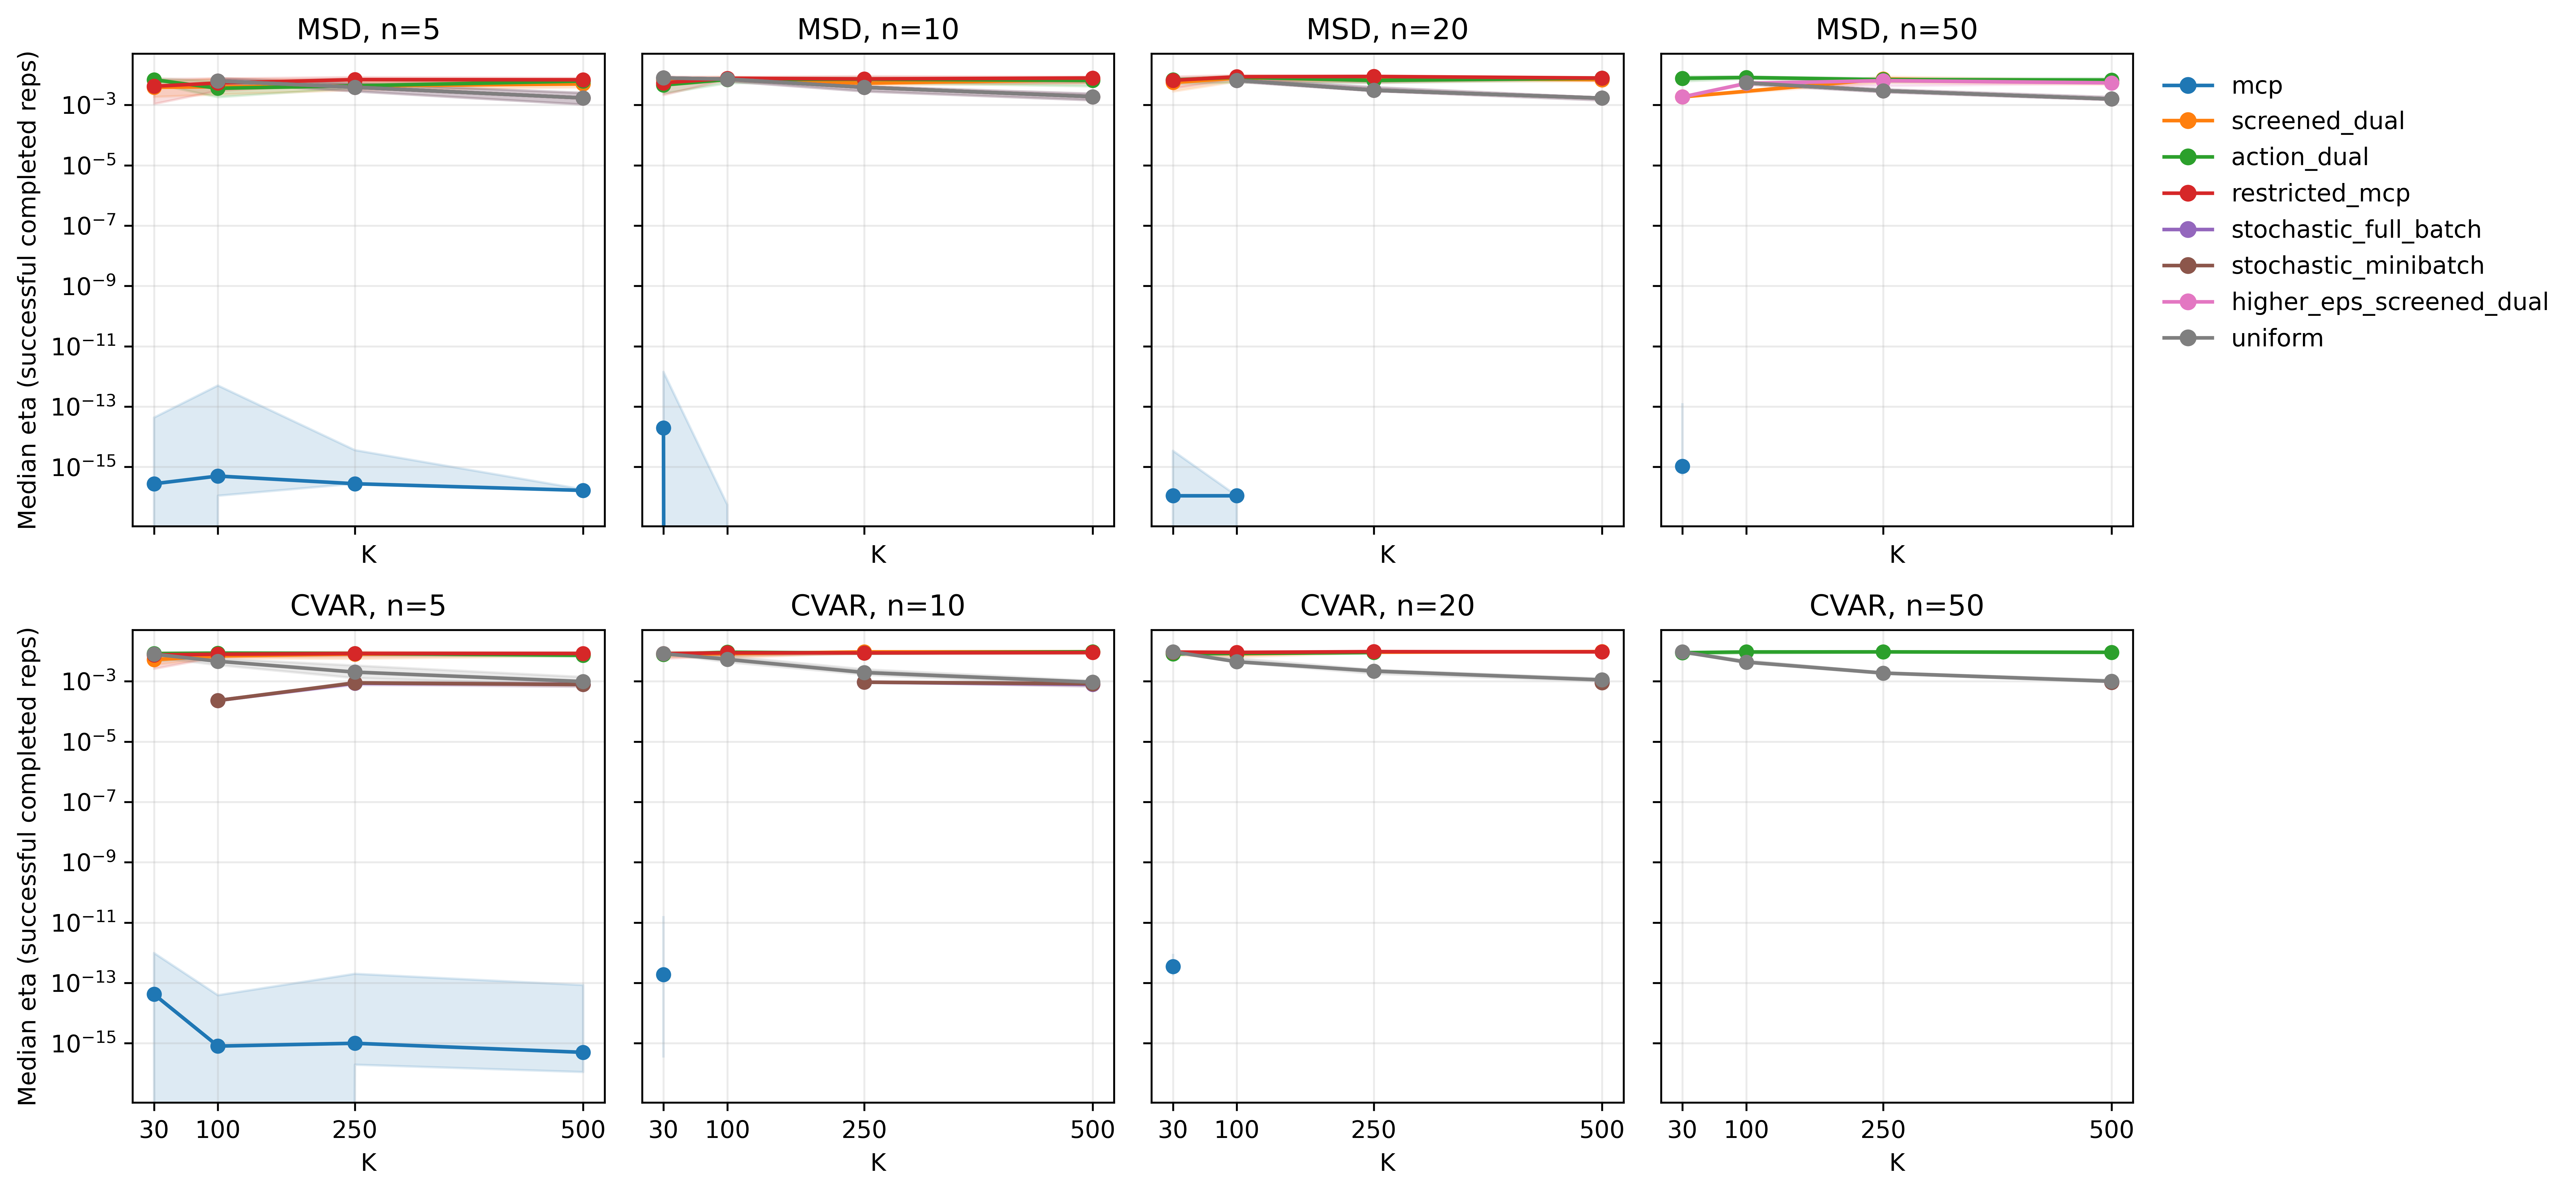

In [8]:
plot_scalability_grid(
    scalability_summary,
    "eta_median",
    "Median eta (successful completed reps)",
    q25="eta_q25",
    q75="eta_q75",
    yscale="log",
)
plt.show()

# Hyperparameter tuning using pilots for stochastic algorithms

Each loaded shard and method defines one continuation trajectory. Running-best eta and improvement therefore carry across changes in $\kappa$ and $\tau$ between stages, while distinct shards and methods remain separate. The eta figures show one shared trajectory panel per risk, with color identifying the initial step-size experiment.

In [9]:
V2_ROOT = RESULTS_DIR / "stochastic/continuation_shards/v2"
v2_summary, v2_history = sa.load_stochastic_shards(V2_ROOT)
v2_best_history = sa.prepare_best_eta_history(v2_history)
v2_improvement_history = sa.prepare_eta_improvement(v2_history)

In [10]:
v2_summary.groupby(["K", "n", "entropy_kappa", "smoothing_tau", "step_size"])[
    [
        "full_batch_eta",
        "full_batch_best_objective",
        "full_batch_best_certificate_eta",
        "full_batch_best_certificate_iteration",
        "minibatch_eta",
        "minibatch_best_objective",
        "minibatch_best_certificate_eta",
        "minibatch_best_certificate_iteration",
    ]
].median()

full_batch_eta  \
K   n  entropy_kappa smoothing_tau step_size                   
250 20 0.1           0.02          5.0              0.002134   
                                   10.0             0.001847   
                                   15.0             0.001742   

                                              full_batch_best_objective  \
K   n  entropy_kappa smoothing_tau step_size                              
250 20 0.1           0.02          5.0                         0.125308   
                                   10.0                        0.125271   
                                   15.0                        0.125146   

                                              full_batch_best_certificate_eta  \
K   n  entropy_kappa smoothing_tau step_size                                    
250 20 0.1           0.02          5.0                               0.002134   
                                   10.0                              0.001847   
                                   15.0                              0.001742   

                                              full_batch_best_certificate_iteration  \
K   n  entropy_kappa smoothing_tau step_size                                          
250 20 0.1           0.02          5.0                                      14000.0   
                                   10.0                                     14000.0   
                                   15.0                                     14000.0   

                                              minibatch_eta  \
K   n  entropy_kappa smoothing_tau step_size                  
250 20 0.1           0.02          5.0             0.002219   
                                   10.0            0.001996   
                                   15.0            0.001814   

                                              minibatch_best_objective  \
K   n  entropy_kappa smoothing_tau step_size                             
250 20 0.1           0.02          5.0                        0.125191   
                                   10.0                       0.125170   
                                   15.0                       0.125164   

                                              minibatch_best_certificate_eta  \
K   n  entropy_kappa smoothing_tau step_size                                   
250 20 0.1           0.02          5.0                              0.002219   
                                   10.0                             0.001996   
                                   15.0                             0.001814   

                                              minibatch_best_certificate_iteration  
K   n  entropy_kappa smoothing_tau step_size                                        
250 20 0.1           0.02          5.0                                     14000.0  
                                   10.0                                    14000.0  
                                   15.0                                    14000.0

In [11]:
v2_summary[
    [
        column
        for column in v2_summary.columns
        if "eta" in column or "time" in column or "iteration" in column
    ]
    + ["K", "n", "entropy_kappa", "smoothing_tau", "step_size"]
]

,full_batch_time_s,full_batch_solve_time_s,full_batch_eta,full_batch_iterations,full_batch_best_certificate_eta,full_batch_best_certificate_iteration,full_batch_theta1,full_batch_theta2,minibatch_time_s,minibatch_solve_time_s,...,minibatch_best_certificate_iteration,minibatch_theta1,minibatch_theta2,eta_diff_minibatch_minus_full_batch,time_ratio_minibatch_over_full_batch,K,n,entropy_kappa,smoothing_tau,step_size
0,2877.546508,2875.929696,0.001995,14000,0.001995,14000,-5.858241,1.421996,3420.646905,3419.972102,...,12100,2.006663,5.100873,1.196146e-04,1.188737,250,20,0.1,0.02,10.0
1,2862.777362,2861.188764,0.001632,14000,0.001632,4000,9.806387,-13.907476,3406.049517,3405.360575,...,12300,-1.291562,0.795199,5.548599e-04,1.189771,250,20,0.1,0.02,10.0
2,2865.756297,2864.137374,0.001654,14000,0.001654,14000,3.880588,-3.282333,3416.078549,3415.418163,...,14000,-2.155195,-1.684414,2.240925e-04,1.192034,250,20,0.1,0.02,10.0
3,2883.449920,2881.768501,0.001816,14000,0.001816,10000,-13.236663,13.342903,3429.231022,3428.533286,...,12100,2.760505,7.402029,1.155348e-04,1.189281,250,20,0.1,0.02,15.0
4,3365.231078,3363.051172,0.001623,14000,0.001623,4000,4.875763,-22.783912,1477.960965,1477.645422,...,14000,-2.186999,-14.062002,2.350372e-04,0.439186,250,20,0.1,0.02,15.0
5,1560.289368,1558.221307,0.001770,14000,0.001770,14000,-0.009684,-7.895789,1021.754239,1021.530564,...,14000,-3.483180,-2.776782,3.645617e-11,0.654849,250,20,0.1,0.02,15.0
6,2865.795389,2864.146302,0.002272,14000,0.002272,14000,-1.126862,5.575902,3405.183430,3404.515154,...,14000,1.252821,2.799717,9.474213e-05,1.188216,250,20,0.1,0.02,5.0
7,2881.869256,2880.278224,0.001648,14000,0.001648,5600,8.364939,-3.920609,3424.210573,3423.510832,...,12300,-0.396126,3.681998,5.735992e-04,1.188191,250,20,0.1,0.02,5.0
8,2887.107591,2885.479332,0.001838,14000,0.001838,14000,2.298828,-0.451478,3428.345463,3427.643110,...,14000,-0.827210,-0.592046,1.782242e-04,1.187467,250,20,0.1,0.02,5.0
9,1480.728276,1479.356182,0.001845,14000,0.001845,14000,NaN,NaN,1433.791768,1433.483551,...,14000,NaN,NaN,2.349792e-05,0.968302,250,20,0.1,0.02,10.0


In [12]:
def plot_eta_history(prepared_history, K, n, method):
    h = prepared_history.loc[
        prepared_history["K"].eq(K)
        & prepared_history["n"].eq(n)
        & prepared_history["method"].eq(method)
    ]
    if h.empty:
        return None

    g = sns.relplot(
        data=h,
        x="iteration",
        y="best_eta",
        col="risk",
        hue="step_size",
        kind="line",
        estimator="median",
        errorbar=("pi", 50),
        palette="viridis",
        height=4,
        aspect=1.25,
        facet_kws={"sharex": True, "sharey": True},
    )
    for ax in g.axes.flat:
        ax.axhline(1e-3, color="black", linestyle="--", linewidth=1)
        ax.grid(alpha=0.2)
    g.set_axis_labels("Iteration", "Best certified eta")
    g.set_titles("risk={col_name}")
    g.fig.suptitle(f"{method}: K={K}, n={n}", y=1.02)
    return g


def plot_eta_improvement(prepared_history, K, n, method):
    h = prepared_history.loc[
        prepared_history["K"].eq(K)
        & prepared_history["n"].eq(n)
        & prepared_history["method"].eq(method)
    ]
    if h.empty:
        return None

    g = sns.relplot(
        data=h,
        x="iteration",
        y="eta_improvement_pct",
        col="risk",
        hue="step_size",
        kind="line",
        estimator="median",
        errorbar=("pi", 50),
        palette="viridis",
        height=4,
        aspect=1.25,
    )
    for ax in g.axes.flat:
        ax.axhline(0, color="black", linewidth=1)
        ax.grid(alpha=0.2)
    g.set_axis_labels("Iteration", "Improvement over initial eta (%)")
    g.set_titles("risk={col_name}")
    g.fig.suptitle(f"{method}: K={K}, n={n}", y=1.02)
    return g


def plot_eta_objective(history, K, n):
    h = history.loc[history["K"].eq(K) & history["n"].eq(n)].copy()
    if h.empty:
        return None

    # Preserve the original diagnostic exclusion, but apply it to the filtered data.
    cvar_residual_mask = (
        h["risk"].eq("cvar") & h["entropy_kappa"].eq(0.1) & h["residual_norm"].lt(0.6)
    )
    plot_data = h.loc[~cvar_residual_mask]
    if plot_data.empty:
        return None

    g = sns.relplot(
        data=plot_data,
        x="residual_norm",
        y="eta",
        row="risk",
        hue="entropy_kappa",
        style="method",
        col="step_size",
        kind="scatter",
        height=3.2,
        facet_kws={"sharex": False, "sharey": True},
    )
    for ax in g.axes.flat:
        ax.grid(alpha=0.2)
    g.set_titles(r"risk={row_name}, step_size=${col_name}$")
    g.fig.suptitle(f"K={K}, n={n}", y=1.02)
    return g

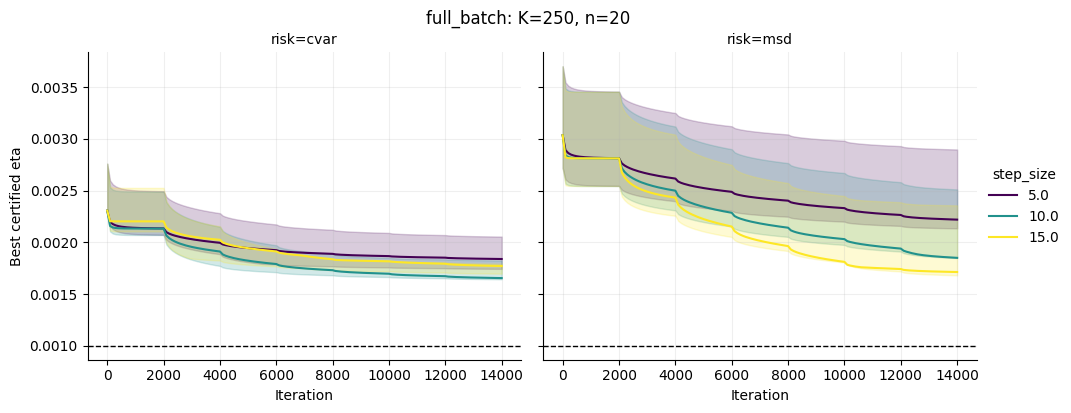

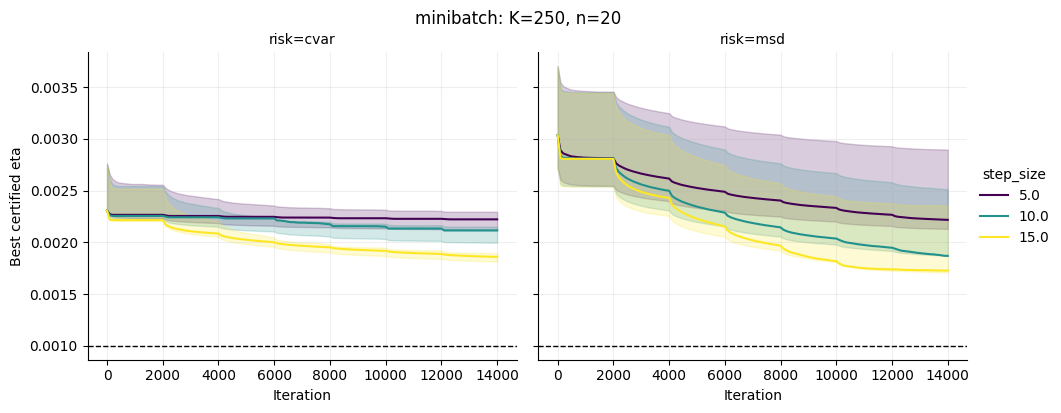

In [13]:
v2_combinations = (
    v2_history[["K", "n", "method"]].drop_duplicates().sort_values(["method", "K", "n"])
)

for row in v2_combinations.itertuples(index=False):
    plot_eta_history(v2_best_history, K=row.K, n=row.n, method=row.method)
    plt.show()

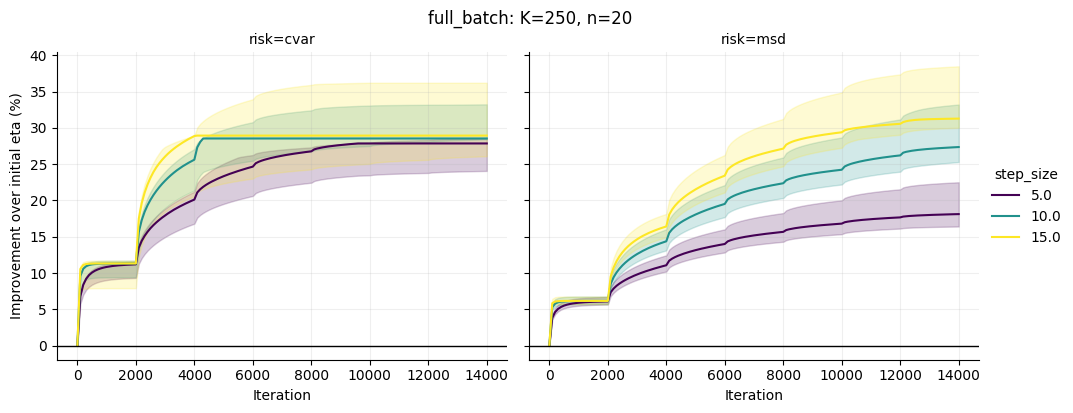

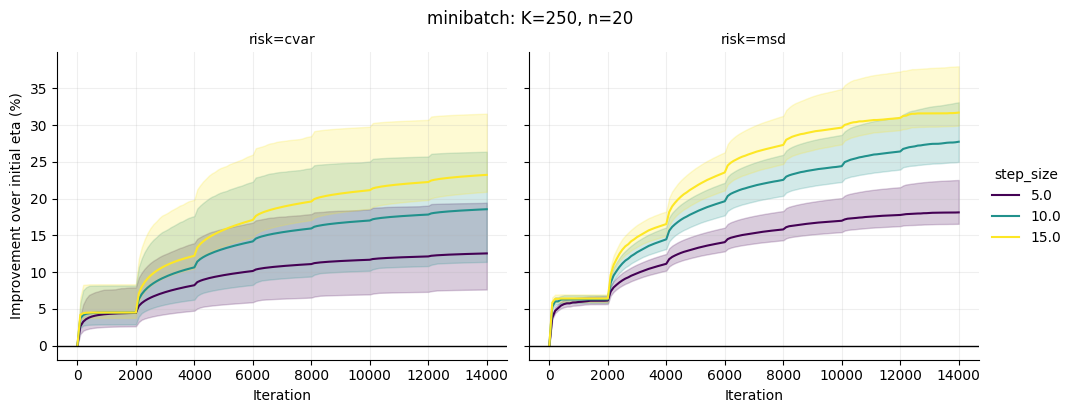

In [14]:
for row in v2_combinations.itertuples(index=False):
    plot_eta_improvement(v2_improvement_history, K=row.K, n=row.n, method=row.method)
    plt.show()

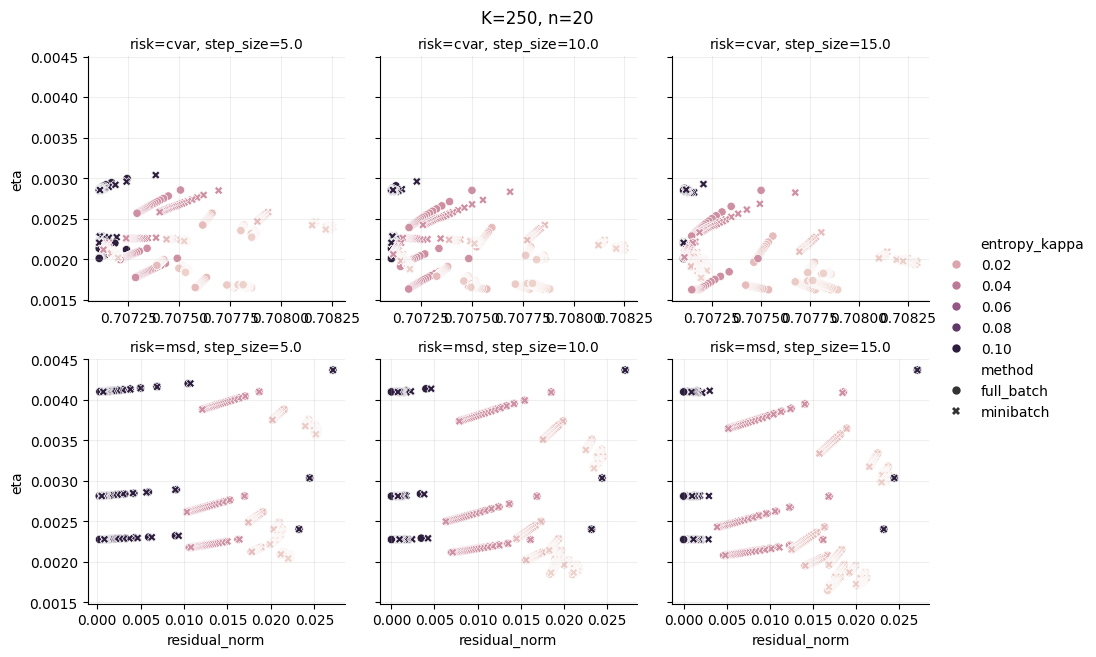

In [15]:
for row in (
    v2_history[["K", "n"]]
    .drop_duplicates()
    .sort_values(["K", "n"])
    .itertuples(index=False)
):
    plot_eta_objective(v2_history, K=row.K, n=row.n)
    plt.show()

## v3 continuation pilots

In [16]:
V3_ROOT = RESULTS_DIR / "stochastic/continuation_shards/v3"
v3_summary, v3_history = sa.load_stochastic_shards(V3_ROOT)

warning_shards = {
    path.stem
    for path in (V3_ROOT / "logs").glob("*.log")
    if "RuntimeWarning" in path.read_text()
}
v3_summary["had_runtime_warning"] = v3_summary["shard"].isin(warning_shards)

v3_long = sa.stochastic_summary_to_long(v3_summary)
v3_long["initial_step"] = v3_long["step_size"]
v3_long.groupby(["risk", "method", "initial_step"]).agg(
    reps=("eta", "size"),
    successes=("success", "sum"),
    min_eta=("eta", "min"),
    median_eta=("eta", "median"),
    max_eta=("eta", "max"),
    median_time_s=("time_s", "median"),
    median_iterations=("iterations", "median"),
    warning_rate=("had_runtime_warning", "mean"),
)

reps  successes   min_eta  median_eta   max_eta  \
risk method     initial_step                                                    
cvar full_batch 15.0             3          0  0.001628    0.001975  0.002125   
                20.0             3          0  0.001625    0.001796  0.001816   
                25.0             3          0  0.001624    0.001885  0.001891   
     minibatch  15.0             3          0  0.001975    0.002049  0.002234   
                20.0             3          0  0.001796    0.001876  0.001898   
                25.0             3          0  0.001885    0.001978  0.002049   
msd  full_batch 15.0             3          0  0.002009    0.002198  0.003482   
                20.0             3          0  0.001687    0.001739  0.003058   
                25.0             3          0  0.001899    0.002003  0.003225   
     minibatch  15.0             3          0  0.002009    0.002199  0.003474   
                20.0             3          0  0.001702    0.001750  0.003029   
                25.0             3          0  0.001905    0.002007  0.003203   

                              median_time_s  median_iterations  warning_rate  
risk method     initial_step                                                  
cvar full_batch 15.0             738.199056             4600.0           1.0  
                20.0             893.176097             5600.0           1.0  
                25.0             793.063920             4800.0           1.0  
     minibatch  15.0             794.105722             4600.0           1.0  
                20.0            1127.848556             7500.0           1.0  
                25.0             688.726722             4800.0           1.0  
msd  full_batch 15.0             342.608923             5000.0           1.0  
                20.0             578.127730             8000.0           1.0  
                25.0             420.104371             6200.0           1.0  
     minibatch  15.0             342.484024             4900.0           1.0  
                20.0             608.591235             7600.0           1.0  
                25.0             514.096325             6800.0           1.0

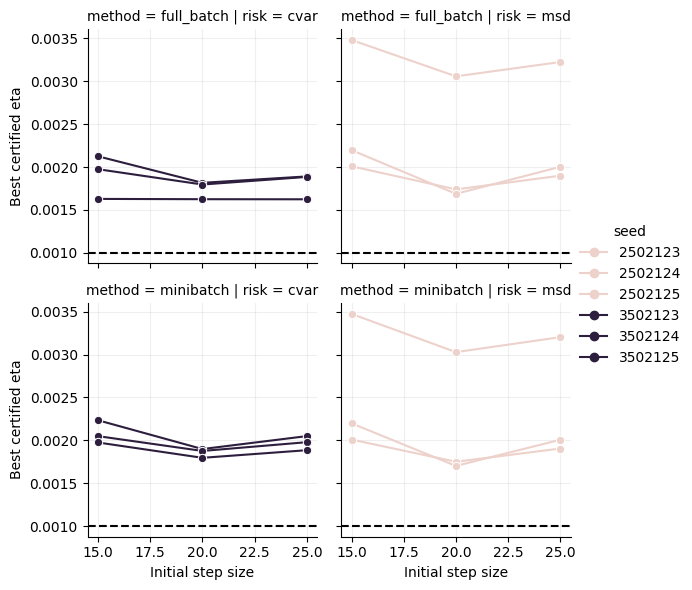

In [17]:
g = sns.relplot(
    data=v3_long,
    x="initial_step",
    y="eta",
    row="method",
    col="risk",
    hue="seed",
    units="seed",
    estimator=None,
    marker="o",
    kind="line",
    height=3,
)
for ax in g.axes.flat:
    ax.axhline(1e-3, color="black", linestyle="--")
    ax.grid(alpha=0.2)
g.set_axis_labels("Initial step size", "Best certified eta")

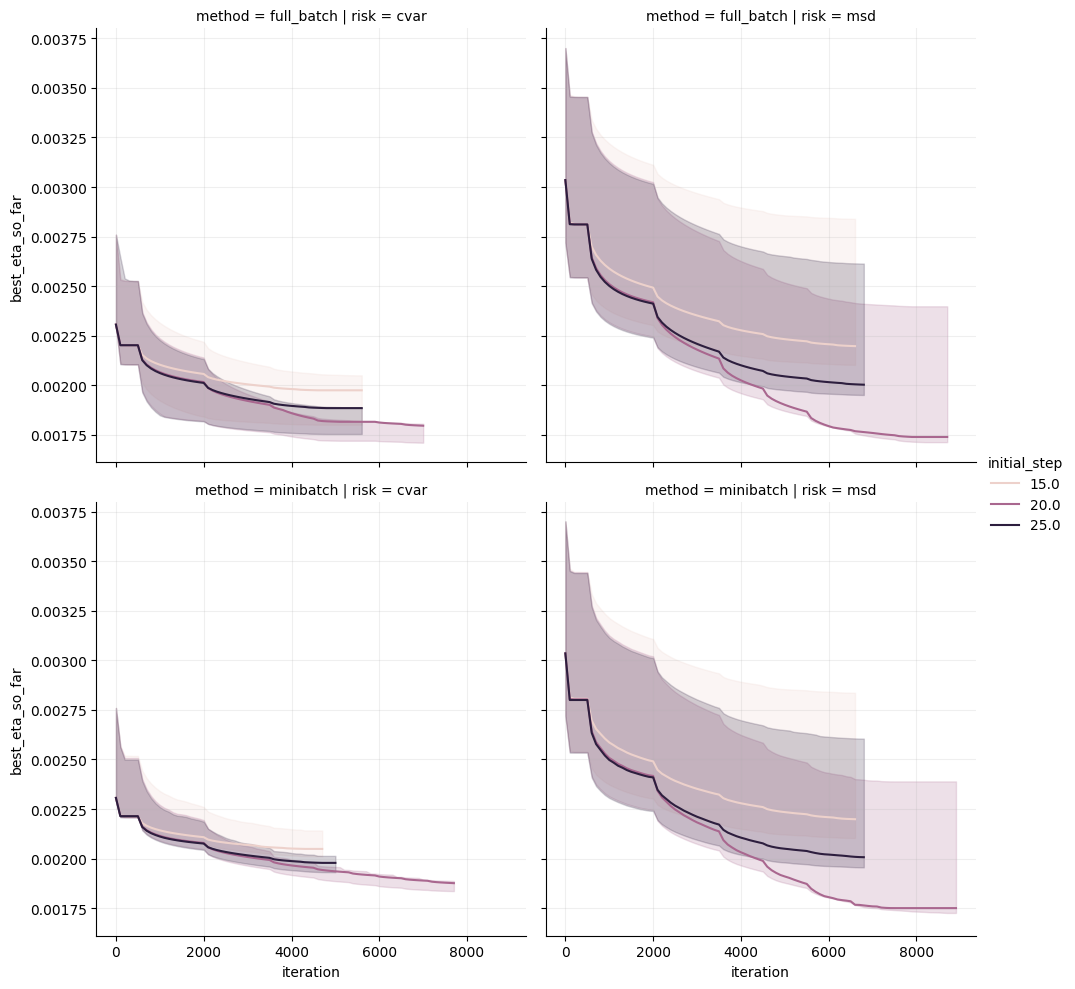

In [18]:
v3_history_prepared = sa.prepare_v3_plot_history(v3_history, v3_summary)

g = sns.relplot(
    data=v3_history_prepared,
    x="iteration",
    y="best_eta_so_far",
    row="method",
    col="risk",
    hue="initial_step",
    kind="line",
    estimator="median",
    errorbar=("pi", 50),
    height=5,
)
for ax in g.axes.flat:
    ax.grid(alpha=0.2)